# Analiza najbolje ocenjenih albumov (AlbumOfTheYear)

Projektna naloga se osredotoča na podatke o 500 najbolje ocenjenih albumih vseh časov, pridobljene s strani [AlbumOfTheYear](https://www.albumoftheyear.org/ratings/6-highest-rated/all/1). Za vsak album poznamo izvajalca, naslov, datum izida, žanre, kritiško oceno (0-100), število recenzij in platforme, na katerih je album na voljo.

## 1. Nalaganje in priprava podatkov

Podatke naložimo enkrat na začetku in tu tudi izvedemo vse pretvorbe tipov (ocena, datum, žanri, platforme, desetletje), da so v vseh nadaljnjih celicah že pripravljeni za uporabo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('podatki/albumi.csv')

# pretvorba v številske/datumske tipe (v CSV-ju so shranjeni kot besedilo)
df['ocena'] = pd.to_numeric(df['ocena'], errors='coerce')
df['st_recenzij'] = pd.to_numeric(df['st_recenzij'], errors='coerce')
df['leto'] = pd.to_numeric(df['leto'], errors='coerce')
df['mesec'] = pd.to_numeric(df['mesec'], errors='coerce')
df['datum_izida'] = pd.to_datetime(df['datum_izida'], errors='coerce')

# odstranimo vrstice brez ocene ali leta - brez njiju vrstica ni uporabna
pred = len(df)
df = df.dropna(subset=['ocena', 'leto']).copy()
df['leto'] = df['leto'].astype(int)
print(f'Odstranjenih vrstic zaradi manjkajočih podatkov: {pred - len(df)}')

# žanre in platforme razbijemo v sezname za kasnejšo analizo posameznih vrednosti
# (ta dva stolpca sta samo za interno rabo, zato ju pri izpisu tabel izpustimo)
df['zanri_seznam'] = df['zanri'].fillna('').apply(
    lambda s: [z.strip() for z in s.split(',') if z.strip()]
)
df['platforme_seznam'] = df['platforme'].fillna('').apply(
    lambda s: [p.strip() for p in s.split(',') if p.strip()]
)

df['desetletje'] = (df['leto'] // 10) * 10

# slovenska imena stolpcev - uporabimo jih samo pri izpisu tabel,
# notranje delo s podatki (df['zanri'] ipd.) ostane nespremenjeno
IMENA_STOLPCEV = {
    'izvajalec': 'Izvajalec',
    'naslov': 'Naslov',
    'datum_izida': 'Datum izida',
    'leto': 'Leto',
    'mesec': 'Mesec',
    'zanri': 'Žanri',
    'ocena': 'Ocena',
    'st_recenzij': 'Št. recenzij',
    'platforme': 'Platforme',
    'desetletje': 'Desetletje',
}
# stolpci, ki jih dejansko prikažemo v tabelah (brez pomožnih *_seznam stolpcev)
PRIKAZNI_STOLPCI = ['izvajalec', 'naslov', 'datum_izida', 'leto', 'mesec',
                     'zanri', 'ocena', 'st_recenzij', 'platforme', 'desetletje']

print(f'Skupaj albumov: {len(df)}')
df[PRIKAZNI_STOLPCI].rename(columns=IMENA_STOLPCEV).head(10)

Odstranjenih vrstic zaradi manjkajočih podatkov: 0
Skupaj albumov: 500


,Izvajalec,Naslov,Datum izida,Leto,Mesec,Žanri,Ocena,Št. recenzij,Platforme,Desetletje
0,Kendrick Lamar,To Pimp a Butterfly,2015-03-15,2015,3.0,"Conscious Hip Hop, Jazz Rap, West Coast Hip Ho...",95,47,"Amazon, Amazon (Vinyl), Apple Music, SoundClou...",2010
1,The Beatles,Revolver,1966-08-05,1966,8.0,"Pop Rock, Psychedelic Pop Psychedelic Rock, Ex...",100,9,"Amazon, Amazon (Vinyl), Apple Music, Spotify",1960
2,Prince,"Sign ""☮︎"" the Times",1987-03-31,1987,3.0,"Contemporary R&B Synth Funk, Pop Rock, Minneap...",99,9,"Amazon, Apple Music, Spotify",1980
3,The Beatles,Abbey Road,1969-09-26,1969,9.0,"Pop Rock Progressive Pop, Psychedelic Pop, Art...",100,8,"Amazon, Amazon (Vinyl), Apple Music, Spotify",1960
4,Nick Cave and the Bad Seeds,Ghosteen,2019-10-04,2019,10.0,"Singer-Songwriter Spoken Word, New Age, Ambient",93,37,"Amazon, Apple Music, Spotify",2010
5,The Beatles,Rubber Soul,1965-12-03,1965,12.0,"Pop Rock Folk Rock, Psychedelic Pop, Folk Pop,...",100,8,"Amazon, Amazon (Vinyl), Apple Music, Spotify",1960
6,Kendrick Lamar,DAMN.,2017-04-14,2017,4.0,"Conscious Hip Hop, West Coast Hip Hop Pop Rap,...",93,44,"Amazon, Amazon (Vinyl), Apple Music, SoundClou...",2010
7,Fiona Apple,Fetch the Bolt Cutters,2020-04-17,2020,4.0,"Art Pop, Singer-Songwriter, Progressive Pop Pi...",93,35,"Amazon, Amazon (Vinyl), Apple Music, SoundClou...",2020
8,Eno,Another Green World,1975-11-14,1975,11.0,"Art Rock, Ambient Electronic, Art Pop",99,8,"Amazon, Amazon (Vinyl), Apple Music, Spotify",1970
9,Public Enemy,It Takes a Nation of Millions to Hold Us Back,1988-06-28,1988,6.0,"Hardcore Hip Hop, East Coast Hip Hop, Consciou...",99,8,"Amazon, Apple Music, SoundCloud, Spotify",1980


## 2. Porazdelitev ocen

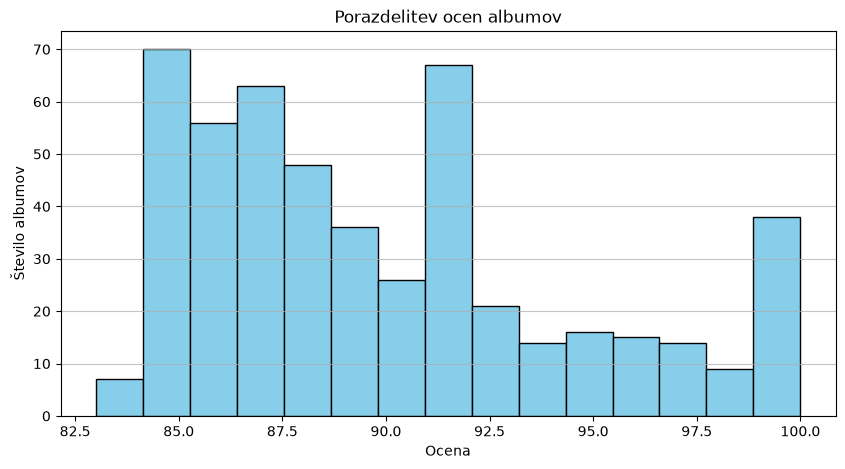

In [4]:
plt.figure(figsize=(10, 5))
plt.hist(df['ocena'], bins=15, color='skyblue', edgecolor='black')
plt.title('Porazdelitev ocen albumov')
plt.xlabel('Ocena')
plt.ylabel('Število albumov')
plt.grid(axis='y', alpha=0.75)
plt.show()

Ocene razdelimo tudi v razrede, da lažje vidimo deleže na tortnem diagramu:

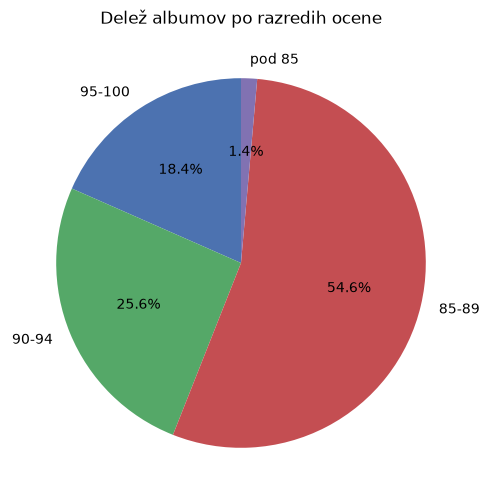

Povprečna ocena: 90.0, najnižja: 83
razred_ocene
95-100     92
90-94     128
85-89     273
pod 85      7
Name: count, dtype: int64


In [5]:
def razred_ocene(ocena):
    if ocena >= 95:
        return '95-100'
    elif ocena >= 90:
        return '90-94'
    elif ocena >= 85:
        return '85-89'
    else:
        return 'pod 85'

df['razred_ocene'] = df['ocena'].apply(razred_ocene)
vrstni_red = ['95-100', '90-94', '85-89', 'pod 85']
stevilo_po_razredu = df['razred_ocene'].value_counts().reindex(vrstni_red).fillna(0)

plt.figure(figsize=(6, 6))
plt.pie(stevilo_po_razredu, labels=stevilo_po_razredu.index, autopct='%1.1f%%',
        colors=['#4C72B0', '#55A868', '#C44E52', '#8172B2'], startangle=90)
plt.title('Delež albumov po razredih ocene')
plt.show()

print(f"Povprečna ocena: {df['ocena'].mean():.1f}, najnižja: {df['ocena'].min():.0f}")
print(stevilo_po_razredu)

Kakor vidimo, je porazdelitev ocen zgoščena tam pri 85 do 89-tih točkah, kjer leži 54,6% albumov, sledi en razred višje pri 90 do 94-tih(25,6% albumov), rekel bi da je to kar smiselno, saj govorimo o najboljših albumih vseh časov, da bi bili vsi pri visokih 90-tih točkah pa je težko pričakovati, saj so te rezervirane res za prave mojstrovine. Prav tako lahko rečemo za tiste malo nižje ocenjene in zakaj jih je toliko manj, za najboljše albume je seveda logično pričakovati oceno vsaj nad 85.

## 3. Top 10 albumov

In [7]:
top10 = df.sort_values(by='ocena', ascending=False).head(10)
display(top10[['izvajalec', 'naslov', 'leto', 'ocena', 'st_recenzij']]
        .rename(columns=IMENA_STOLPCEV))

,Izvajalec,Naslov,Leto,Ocena,Št. recenzij
31,Metallica,Master of Puppets,1986,100,6
30,The Smiths,The Queen Is Dead,1986,100,6
75,Elvis Presley,Elvis Presley,1956,100,5
16,Paul Simon,Graceland,1986,100,7
32,Bob Dylan,Blood on the Tracks,1975,100,6
33,Miles Davis,Kind of Blue,1959,100,6
34,Leonard Cohen,Songs of Leonard Cohen,1967,100,6
35,Patti Smith,Horses,1975,100,6
38,Television,Marquee Moon,1977,100,6
74,Big Star,3rd,1978,100,5


Iz vzorca desetih najvišje ocenjenih albumov je moč videti, da jih ima vseh 10 oceno 100, če smo pozorni lahko vidimo, da imajo vsi od 5 pa do 7 recenzij, torej najvišje ocenjeni albumi niso tisti z največ recenzijami.

## 4. Izvajalci z največ albumi na lestvici

In [9]:
stevilo_po_izvajalcu = df['izvajalec'].value_counts()
display(stevilo_po_izvajalcu.head(10).rename_axis('Izvajalec').rename('Število albumov'))

top_izvajalci = df.groupby('izvajalec').filter(lambda x: len(x) >= 2)
povprecne_ocene = top_izvajalci.groupby('izvajalec')['ocena'].mean().sort_values(ascending=False)
display(povprecne_ocene.head(10).rename_axis('Izvajalec').rename('Povprečna ocena'))

Izvajalec
The Beatles          8
David Bowie          6
Bob Dylan            6
Kendrick Lamar       5
Bruce Springsteen    5
Sufjan Stevens       4
Little Simz          4
Tom Waits            4
Mitski               4
St. Vincent          4
Name: Število albumov, dtype: int64

Izvajalec
Stevie Wonder      99.500000
Pixies             99.500000
Grateful Dead      99.000000
Led Zeppelin       98.333333
Miles Davis        98.000000
Michael Jackson    98.000000
The Beatles        97.125000
Nick Drake         97.000000
Pink Floyd         96.666667
Talking Heads      96.500000
Name: Povprečna ocena, dtype: float64

Pri tem razdelku smo bili pozorni na to kateri umetniki imajo največ albumov na tej lestvici. Očitni zmagovalci so The Beatles z osmimi.
Sledila je analiza povprečne ocene na albumov glede na izvajalca, kjer sta pa na samem vrhu Stevie Wonder in pa Pixies.

## 5. Albumi po desetletjih

Desetletje
1950      2
1960     23
1970     64
1980     34
1990     60
2000     68
2010    114
2020    135
Name: Število albumov, dtype: int64

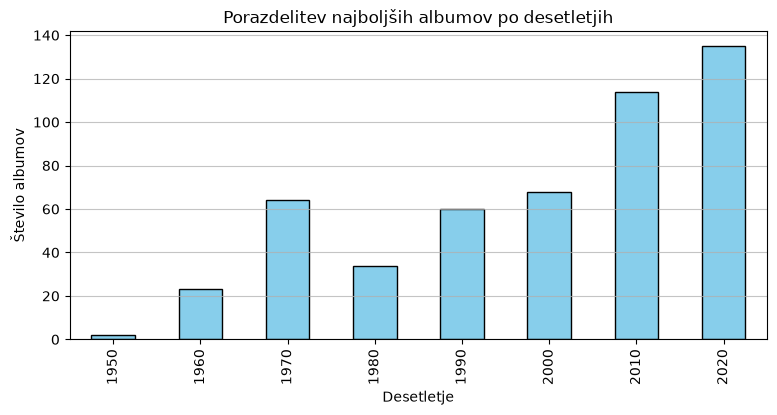

In [11]:
po_desetletju = df['desetletje'].value_counts().sort_index()
display(po_desetletju.rename_axis('Desetletje').rename('Število albumov'))

plt.figure(figsize=(9, 4))
po_desetletju.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Porazdelitev najboljših albumov po desetletjih')
plt.xlabel('Desetletje')
plt.ylabel('Število albumov')
plt.grid(axis='y', alpha=0.75)
plt.show()

Nato me je zanimalo, iz katerega obdobja na našem seznamu izvira največ albumov, oziroma kako je število albumov razdeljeno po desetletjih. Očitna je prevlada dvajsetih let trenutnega tisočletja, to je verjetno posledica tega, da je ustavrjanje glasbe v današnjem času veliko bolj dosegljivo, kot je bilo v prejšnjih desetletjih.

## 6. V katerem mesecu izidejo najbolje ocenjeni albumi?

Glasbena industrija ima znane sezonske vzorce izdaj (npr. veliko izdaj tik pred koncem leta zaradi 'year-end' seznamov) - poglejmo, ali se to pozna tudi na tej lestvici.

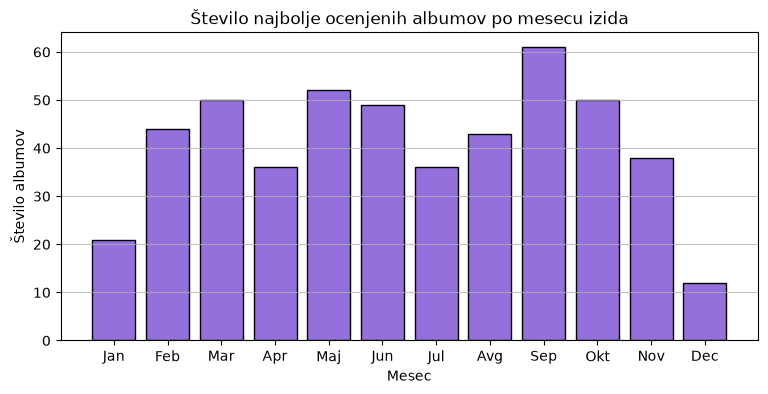

In [13]:
po_mesecu = df.dropna(subset=['mesec'])['mesec'].astype(int).value_counts().sort_index()
imena_mesecev = ['Jan', 'Feb', 'Mar', 'Apr', 'Maj', 'Jun',
                  'Jul', 'Avg', 'Sep', 'Okt', 'Nov', 'Dec']

plt.figure(figsize=(9, 4))
plt.bar([imena_mesecev[m - 1] for m in po_mesecu.index], po_mesecu.values,
        color='mediumpurple', edgecolor='black')
plt.title('Število najbolje ocenjenih albumov po mesecu izida')
plt.xlabel('Mesec')
plt.ylabel('Število albumov')
plt.grid(axis='y', alpha=0.75)
plt.show()

Naslednje vprašanje, ki sem si ga zastavil je če mesec izida albuma vpliva na to koliko uspešen bo. Rezultati so me po eni strani presenetili, saj je decemberskih res malo, po drugi strani je bil pa vpad v decembru pričakovan, saj smo ljudje v prazničnih časih navajeni poslušati "klasične" skladbe za tisti čas, in ne posvečamo toliko pozornosti takratnim izdajam.

## 7. Najpogostejši žanri

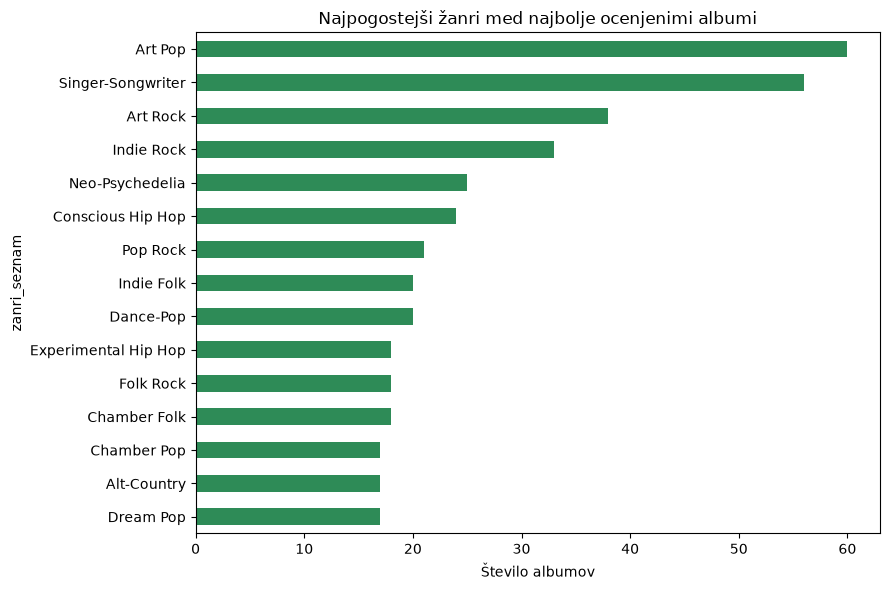

In [15]:
vsi_zanri = df.explode('zanri_seznam')['zanri_seznam']
vsi_zanri = vsi_zanri[vsi_zanri != '']
top_zanri = vsi_zanri.value_counts().head(15)

plt.figure(figsize=(9, 6))
top_zanri.plot(kind='barh', color='seagreen')
plt.xlabel('Število albumov')
plt.title('Najpogostejši žanri med najbolje ocenjenimi albumi')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Marsikdo se bi tudi vprašal kateri so najbolj priljubljeni žanri. Izraziti favorit je v tem primeru Art Pop.

## 8. Razmerje med oceno in številom recenzij

Ali imajo bolj "priljubljeni" albumi (več recenzij) tudi višjo oceno?

Korelacija med oceno in številom recenzij: -0.607


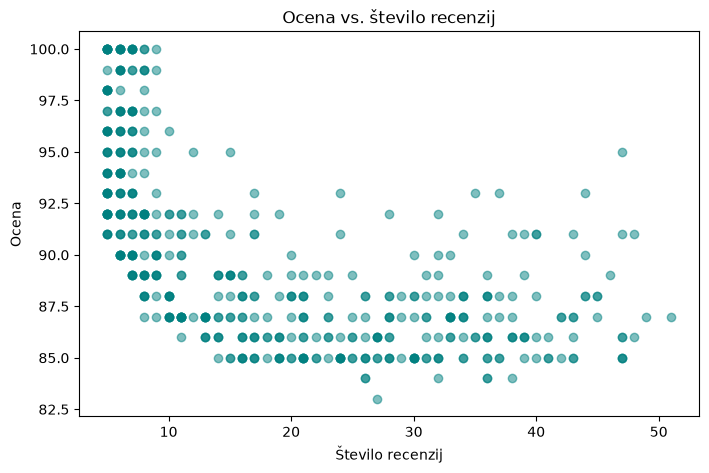

In [17]:
korelacija = df['ocena'].corr(df['st_recenzij'])
print(f'Korelacija med oceno in številom recenzij: {korelacija:.3f}')

plt.figure(figsize=(8, 5))
plt.scatter(df['st_recenzij'], df['ocena'], alpha=0.5, color='teal')
plt.xlabel('Število recenzij')
plt.ylabel('Ocena')
plt.title('Ocena vs. število recenzij')
plt.show()

Še ena pomembna opazka je, da se ocena albuma s številom recenzij načeloma zmanjšuje, ta pojav bi pomojem najlažje opisali z rekom: "vsake oči imajo svojega malarja", saj se pri večjem vzorcu poslušalcev lahko lažje najde nekdo, ki mu album ne bo tako pri godu kot ostalim.

## 9. Na katerih platformah so albumi na voljo

Amazon/Vinyl sta nakupni povezavi (fizični/digitalni nakup), medtem ko so Spotify, Apple Music, SoundCloud in Bandcamp dejanske pretočne platforme za poslušanje.

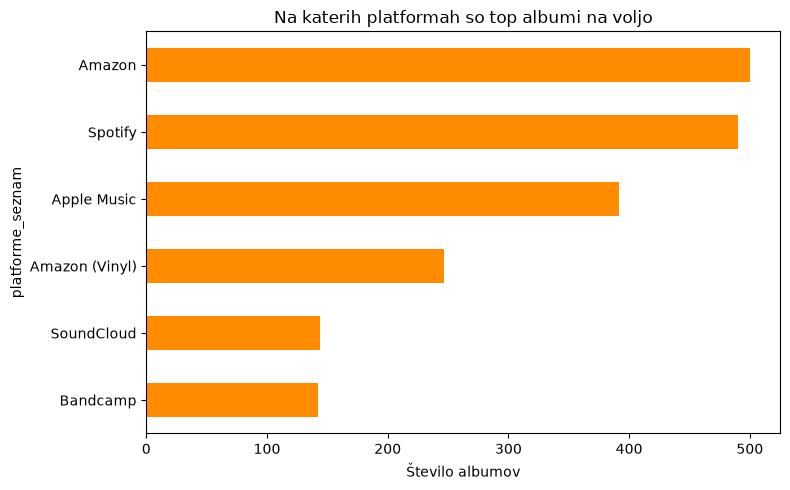

Albumov, ki niso na Spotifyju: 10 od 500


In [19]:
vse_platforme = df.explode('platforme_seznam')['platforme_seznam']
vse_platforme = vse_platforme[vse_platforme != '']
stevilo_platform = vse_platforme.value_counts()

plt.figure(figsize=(8, 5))
stevilo_platform.plot(kind='barh', color='darkorange')
plt.xlabel('Število albumov')
plt.title('Na katerih platformah so top albumi na voljo')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

ni_na_spotify = df[~df['platforme_seznam'].apply(lambda p: 'Spotify' in p)]
print(f'Albumov, ki niso na Spotifyju: {len(ni_na_spotify)} od {len(df)}')

Opazil sem, da stran tudi pove, kje so albumi dostopni. Tukaj imata prevlado Amazon in pa Spotify, kjer tako rekoč lahko prideš do vsakega albuma, na dnu sta pa Soundcloud in Bandcamp, ki sta načeloma zastonj za uporabo, kar ima velik vpliv na vsebine, ki jih ponujata.

## 10. Zaključek

Za analizo sem izbral prvih 500 od skupno približno 5000 albumov na lestvici. Opazil sem, da vrstni red albumov ni strogo urejen po prikazani oceni - AOTY najverjetneje uporablja neko uteženo formulo, ki poleg ocene upošteva tudi število recenzij, podobno kot npr. IMDb pri svoji Top 250 lestvici, saj albumi z zelo malo recenzijami občasno dosežejo najvišje ocene, a niso nujno uvrščeni na sam vrh. Menim, da bi razširitev vzorca na vseh ~5000 albumov le malo spremenila glavne ugotovitve te analize, saj gre proti dnu lestvice za albume z manj kritiškega soglasja - torej bi dodajali predvsem šum, medtem ko so najbolj "kanonizirani" albumi (in s tem tudi prevladujoča desetletja, žanri in izvajalci) že zajeti v prvih 500.